# Build a model to predict the price of a Car in secondhand markets in India.





# Objective: -


### Problem
The second-hand car market in India is booming, with millions of buyers and sellers actively participating every year. However, one of the biggest challenges faced by both buyers and sellers is determining the fair market value of a used car. Factors such as brand reputation, model, age, mileage, condition, and regional demand can significantly impact pricing. Without a reliable and data-driven pricing model, buyers risk overpaying, while sellers may undervalue their vehicles, leading to lost opportunities and inefficiencies in the market.

### Solution we offer
We propose building an advanced machine learning-powered pricing prediction platform tailored specifically for the Indian second-hand car market. This platform will leverage extensive, real-world datasets from Indian automotive platforms and classifieds websites to provide accurate and dynamic price predictions. By analyzing real data—reflecting the true complexity of the market—we aim to create a robust model that accounts for all critical factors influencing car prices, including location, fuel type, kilometers driven, and more.

Our platform can cater to individual buyers and sellers, as well as businesses like dealerships, online car marketplaces, and automotive financing companies.

![Alt text](public\poster.png)

### Key Features:

Fair Pricing Insights: Buyers and sellers can instantly access data-driven price estimates, ensuring transparency and fairness in transactions.  
Personalized Recommendations: Sellers can receive actionable insights on how to price their cars competitively, while buyers can identify the best deals in the market.  
Market Trends Analysis: The platform will offer insights into regional pricing trends, popular car models, and demand fluctuations, empowering users to make informed decisions.  
User-Friendly Interface: A simple, intuitive dashboard will allow users to input car details and receive instant price  

<div style="display: flex; gap: 20px;">
  <img src="public/image2.jpg" alt="Image 1" width="500" />
  <img src="public/image1.jpg" alt="Image 2" width="500" />
</div>

## About dataset
The dataset for this project was sourced from https://app.gigasheet.com/spreadsheet/cars24-com-used-cars-dataset/7a2d62e5_30cf_402c_a8d0_f358da175b14?referrerId=https%3A%2F%2Fwww.gigasheet.com%2Fsample-data%2Fcars24com-used-cars-dataset , a leading online marketplace for used cars in India. The data, collected through web scraping or the platform's API, includes key details such as car make and model, year of manufacture, kilometers driven, fuel type, transmission, location, and price. This real-world dataset reflects the dynamic nature of India's second-hand car market, making it ideal for training machine learning models. I chose this dataset due to its comprehensive coverage of factors influencing car prices and its relevance to the Indian automotive landscape. With thousands of listings across various cities, the dataset provides valuable insights for building an advanced pricing prediction platform tailored to buyers, sellers, and businesses. For more information, visit Cars24.com .

The dataset contains the following columns, each representing specific information about used cars:

1. **Car Name**: The model name of the car.
2. **Year**: The manufacturing year of the car.
3. **Distance**: The total distance the car has traveled, usually measured in kilometers.
4. **Owner**: The number of previous owners the car has had.
5. **Fuel**: The type of fuel the car uses (e.g., Petrol, Diesel).
6. **Location**: The location code or region where the car is registered.
7. **Drive**: The type of transmission or drive system (e.g., Manual, Automatic).
8. **Type**: The category or type of car (e.g., HatchBack, Sedan, SUV).

# Step 1: Import all the required libraries


In [163]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import sklearn
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import scale 
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.model_selection import KFold, cross_val_score
import plotly.express as px
import plotly.graph_objects as go
import plotly.express as px

import warnings

warnings.filterwarnings('ignore')

# Step 2 : Read dataset and basic details of dataset
Goal:- In this step we are going to read the dataset, view the dataset and analysis the basic details like total number of rows and columns, what are the column data types and see to need to create or delete new column or not.


In this stage we are going to read our problem dataset and have a look on it.

In [67]:
df = pd.read_csv("Dataset\Cars24_data.csv").drop(columns=["Unnamed: 0"])
df.head(10)

,Car Name,Year,Distance,Owner,Fuel,Location,Drive,Type,Price
0,Maruti S PRESSO,2022,3878,1,PETROL,HR-98,Manual,HatchBack,514000
1,Hyundai Xcent,2018,32041,1,PETROL,TN-22,Manual,Sedan,674000
2,Tata Safari,2021,96339,1,DIESEL,TS-08,Automatic,SUV,1952000
3,Maruti Vitara Brezza,2019,51718,1,DIESEL,WB-24,Manual,SUV,690000
4,Tata Tiago,2021,19811,1,PETROL,HR-51,Manual,HatchBack,526000
5,Maruti Swift,2017,70129,1,PETROL,MH-14,Manual,HatchBack,552000
6,Hyundai i20,2012,103781,1,PETROL,NaN,Manual,HatchBack,278000
7,Renault Kwid,2021,31945,2,PETROL,UP-32,Automatic,HatchBack,518000
8,Hyundai Grand i10,2015,39950,1,PETROL,HR-26,Manual,HatchBack,443000
9,Maruti Swift,2018,56697,1,DIESEL,KA-04,Automatic,HatchBack,710350


# Step3: Data Preprocessing

**Why need of Data Preprocessing?**

Preprocessing data is an essential step in data analysis.

Data can contain missing values and irrelevant attributes. To address this situation, we require data preprocessing.

#### The df.shape method shows the shape of the dataset. 

In [68]:
df.shape

(8015, 9)

In [70]:
missing_values = df.isnull().sum()

print(missing_values)

Car Name      1
Year          0
Distance      0
Owner         0
Fuel          0
Location    213
Drive         0
Type          0
Price         0
dtype: int64


There are 1 missing value in carname so I will delete it, and 213 missing value in Location , I will replace it with the most frequent Location value

In [71]:
df.dropna(subset=['Car Name'], inplace=True)

In [75]:
df["Location"].value_counts()

Location
MH-12    286
GJ-01    245
HR-26    228
KA-03    198
TS-07    189
        ... 
TS-27      1
HR-07      1
HR-27      1
TN-34      1
PB-46      1
Name: count, Length: 436, dtype: int64

In location most frequest value is MH-12. So I will replace the missing values with MH-12

In [76]:
df["Location"].fillna("MH-12", inplace=True)

In [77]:
missing_values = df.isnull().sum()

print(missing_values)

Car Name    0
Year        0
Distance    0
Owner       0
Fuel        0
Location    0
Drive       0
Type        0
Price       0
dtype: int64


### Data Type Check for every column

**Why data type check is required?**

Data type check helps us with understanding what type of variables our dataset contains. It helps us with identifying whether to keep that variable or not. If the dataset contains contiguous data, then only float and integer type variables will be beneficial and if we have to classify any value then categorical variables will be beneficial.

In [81]:
column_data_types = df.dtypes
print(column_data_types)

Car Name    object
Year         int64
Distance     int64
Owner        int64
Fuel        object
Location    object
Drive       object
Type        object
Price        int64
dtype: object


# Step 3: Descriptive Analysis

**Goal/Purpose:**  Finding the data distribution of the features. Visualization helps to understand data and also to explain the data to another person.

Things we are going to do in this step:

1. Mean
2. Median
3. Mode
4. Standard Deviation
5. Variance
6. Min value
7. Max value
8. Count Value
9. Quatilers
10. Correlation
11. Skewness

In [82]:
df.describe()

,Year,Distance,Owner,Price
count,8014.000000,8014.000000,8014.000000,8.014000e+03
mean,2016.995009,52626.256676,1.300225,5.748328e+05
std,2.861454,29181.519800,0.510914,2.650835e+05
min,2010.000000,0.000000,1.000000,1.190000e+05
25%,2015.000000,30736.750000,1.000000,3.930000e+05
50%,2017.000000,50369.500000,1.000000,5.350000e+05
75%,2019.000000,71762.500000,2.000000,6.980000e+05
max,2023.000000,971212.000000,4.000000,3.300000e+06


#### The df.describe() method returns description of the data in the DataFrame. If the DataFrame contains numerical data, the description contains these information for each column .
count - The number of not-empty values. mean - The average (mean) value. 

## Visualizing categorical attributes

## PI charts based on Manufacturer and Model

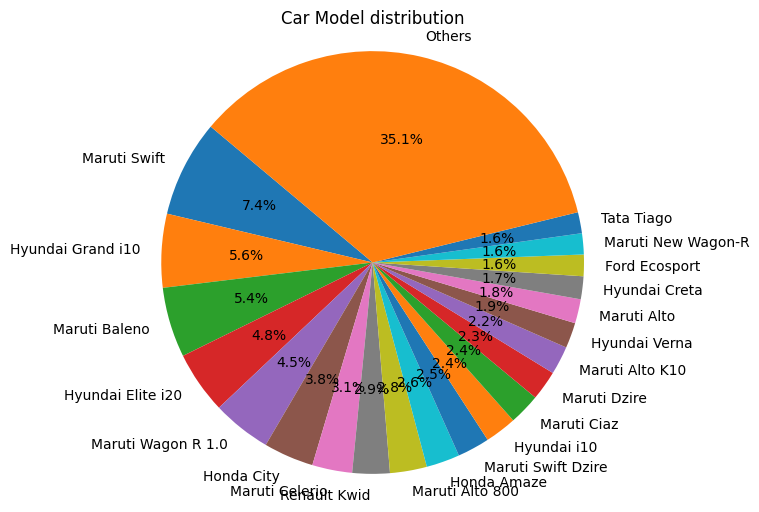

In [94]:
manufacturer_counts = df['Car Name'].value_counts()
total_cars = len(df)
manufacturer_percentages = manufacturer_counts / total_cars * 100

# Combine manufacturers with less than 1.5% share into "Others"
others_mask = manufacturer_percentages < 1.5
others_percentage = manufacturer_percentages[others_mask].sum()
manufacturer_percentages = manufacturer_percentages[~others_mask]
manufacturer_percentages['Others'] = others_percentage

# Plotting the pie chart
plt.figure(figsize=(6, 6))
plt.pie(manufacturer_percentages, labels=manufacturer_percentages.index, autopct='%1.1f%%', startangle=140)
plt.title('Car Model distribution')
plt.axis('equal')
plt.show()

Most selling cars are Maruti Swift, Hyundai Grand i10, Maruti Baleno etc.

## PI chart based on car category .

Sedan , Jeep and Hatchbacks are the most sold category of cars .

## PI chart based on owner type

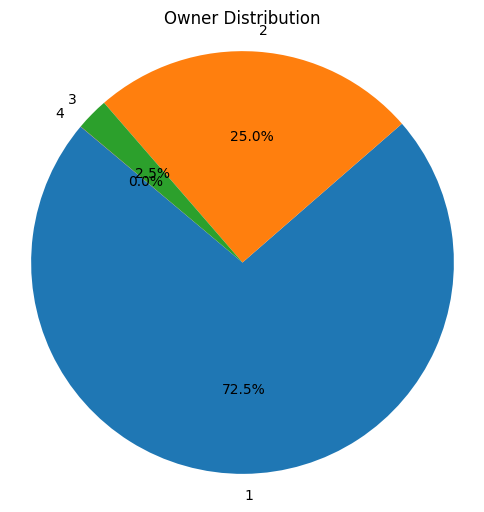

In [93]:
owner_counts = df['Owner'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(owner_counts, labels=owner_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Owner Distribution')
plt.axis('equal')
plt.show()

Most of the cars sold are from 1 st owner

## PI chart based on Fuel type

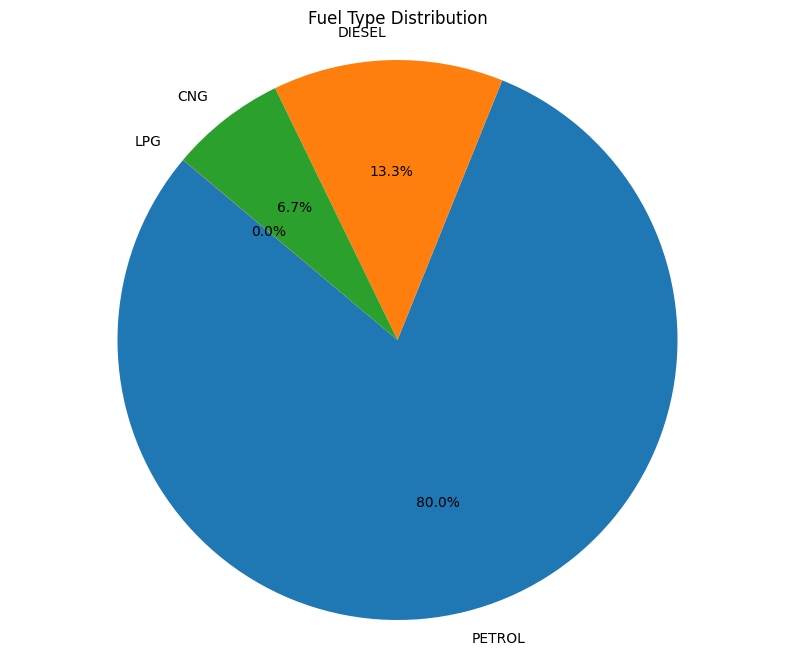

In [98]:
fuel_type_counts = df['Fuel'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(10, 8))
plt.pie(fuel_type_counts, labels=fuel_type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Fuel Type Distribution')
plt.axis('equal') 
plt.show()

Most of the car sold are Petrol cars

## PI chart based on Location

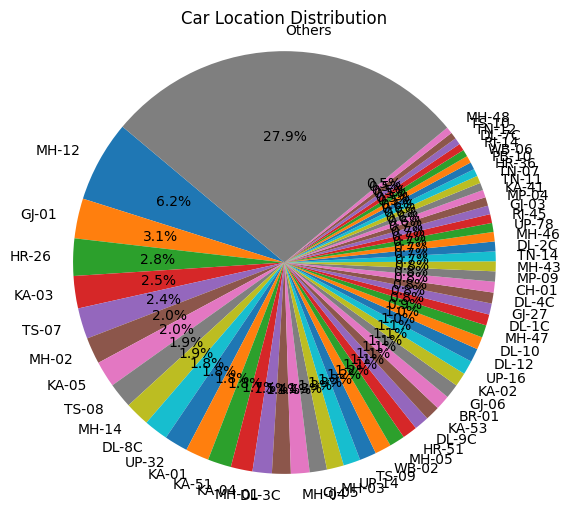

In [102]:
location_counts = df['Location'].value_counts()
total_cars = len(df)
location_percentages = location_counts / total_cars * 100

# Combine Location with less than 1.5% share into "Others"
others_mask = location_percentages < 0.5
others_percentage = location_percentages[others_mask].sum()
location_percentages = location_percentages[~others_mask]
location_percentages['Others'] = others_percentage

# Plotting the pie chart
plt.figure(figsize=(6, 6))
plt.pie(location_percentages, labels=location_percentages.index, autopct='%1.1f%%', startangle=140)
plt.title('Car Location Distribution')
plt.axis('equal')
plt.show()

Most of the cars are from maharastra , Gujrat

## Pychart based on Drive

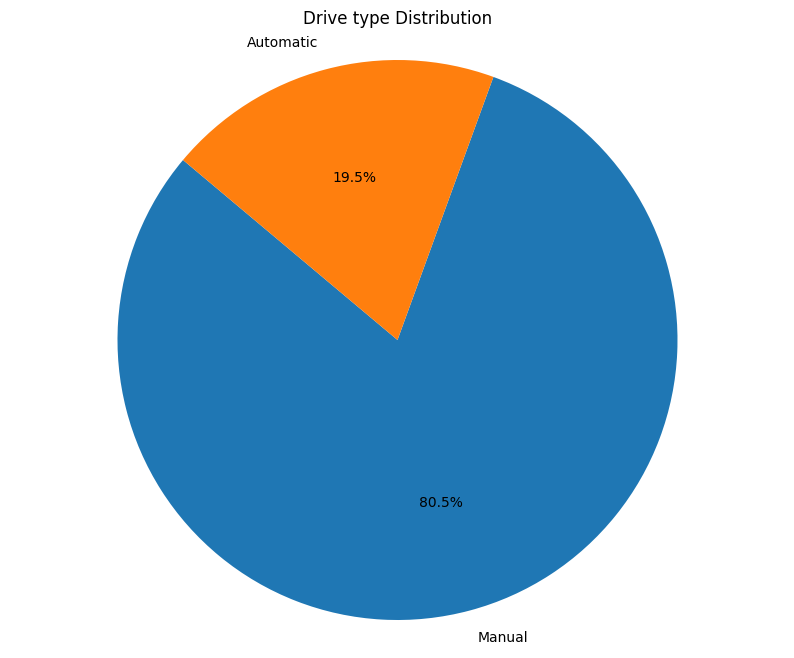

In [105]:
drive_counts = df['Drive'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(10, 8))
plt.pie(drive_counts, labels=drive_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Drive type Distribution')
plt.axis('equal') 
plt.show()

## pychart based on car type

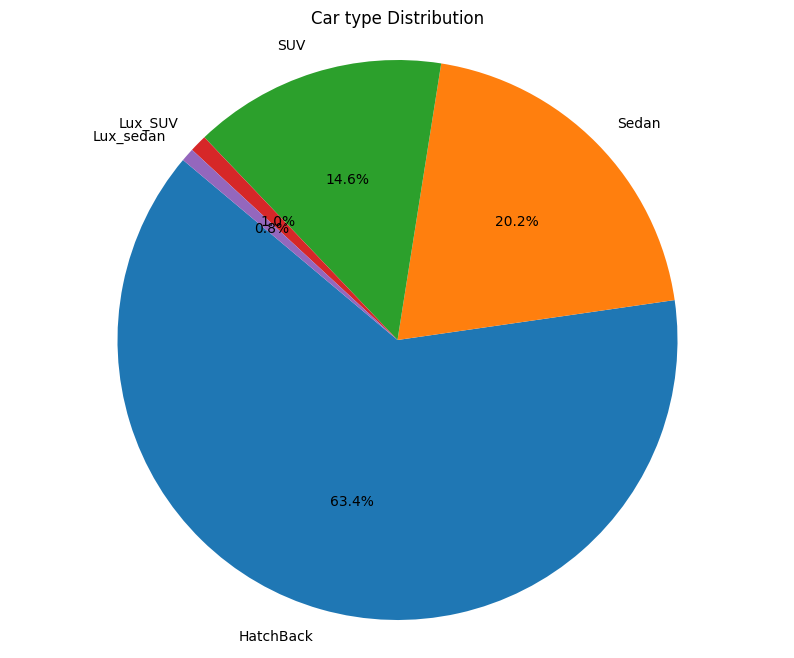

In [107]:
cartype_counts = df['Type'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(10, 8))
plt.pie(drive_counts, labels=cartype_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Car type Distribution')
plt.axis('equal') 
plt.show()

Most of the cars sold are hatchback

# Skewness 

Skewness is a measure of the asymmetry of a distribution. A distribution is asymmetrical when its left and right side are not mirror images. A distribution can have right (or positive), left (or negative), or zero skewness

#### Why do we calculate Skewness ?

Skewness gives the direction of the outliers if it is right-skewed, most of the outliers are present on the right side of the distribution while if it is left-skewed, most of the outliers will present on the left side of the distribution

#### Below is the function to calculate skewness. 

In [109]:
def right_nor_left(df, list):
    
    temp_skewness = ['column', 'skewness_value', 'skewness (+ve or -ve)']
    temp_skewness_values  = []
    
    temp_total = ["positive (+ve) skewed", "normal distrbution" , "negative (-ve) skewed"]
    positive = 0
    negative = 0
    normal = 0
    
    for value in list:
    
        rs = round(df[value].skew(),4)

        if rs > 0:
            temp_skewness_values.append([value,rs , "positive (+ve) skewed"])   
            positive = positive + 1

        elif rs == 0:
            temp_skewness_values.append([value,rs,"normal distrbution"])
            normal = normal + 1

        elif rs < 0:
            temp_skewness_values.append([value,rs, "negative (-ve) skewed"])
            negative = negative + 1
    
    skewness_df =  pd.DataFrame(temp_skewness_values, columns=temp_skewness) 
    skewness_total_df =  pd.DataFrame([[positive, normal, negative]], columns=temp_total) 
    
    return skewness_df, skewness_total_df

In [110]:
float64_cols = ['float64','int32','int64']
float64_lst_col = list(df.select_dtypes(include=float64_cols).columns)

skew_df,skew_total_df = right_nor_left(df, float64_lst_col)

In [111]:
skew_df

,column,skewness_value,skewness (+ve or -ve)
0,Year,-0.4445,negative (-ve) skewed
1,Distance,4.1929,positive (+ve) skewed
2,Owner,1.4370,positive (+ve) skewed
3,Price,1.7493,positive (+ve) skewed


### Why we are calculating all these metrics? 

Mean / Median /Mode/ Variance /Standard Deviation are all very basic but very important concept of statistics used in data science. Almost all the machine learning algorithm uses these concepts in data preprocessing steps. These concepts are part of descriptive statistics where we basically used to describe and understand the data for features in Machine learning

# Step 4: Data Exploration


#### Barplot for Year

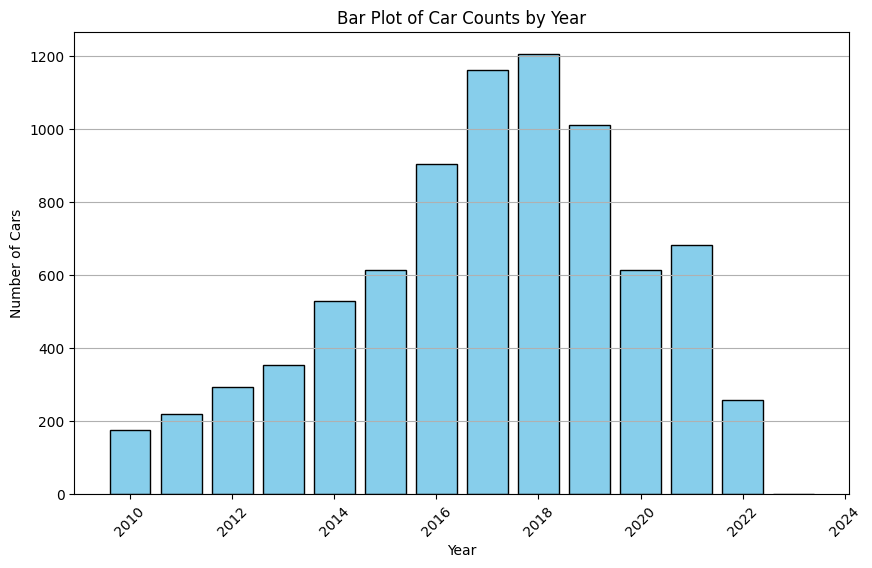

In [127]:
# Count the frequency of each year
year_counts = df['Year'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(year_counts.index, year_counts.values, color='skyblue', edgecolor='black')
plt.title('Bar Plot of Car Counts by Year')
plt.xlabel('Year')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

Histogram on distance

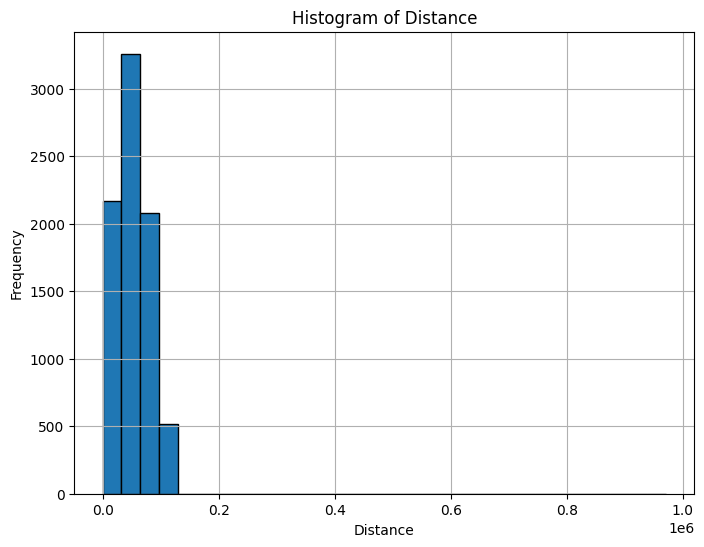

In [134]:

data = df['Distance']

# Create a histogram
plt.figure(figsize=(8, 6))
plt.hist(data, bins=30, edgecolor='black')  # Adjust the number of bins as needed
plt.title('Histogram of Distance')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

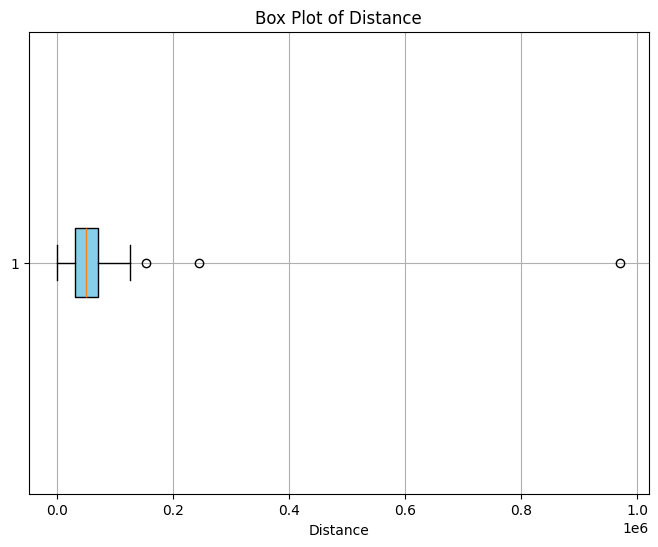

In [135]:
# Sample data
data = df['Distance'] 

# Create a box plot
plt.figure(figsize=(8, 6))
plt.boxplot(data, vert=False, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title('Box Plot of Distance')
plt.xlabel('Distance')
plt.grid(True)
plt.show()

Using barplot and box plot we can see that some of the values here are outliers, and the number of outliers is also very less, so we can saftly remove them.

In [137]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for the 'Distance' column
Q1 = df['Distance'].quantile(0.25)
Q3 = df['Distance'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers from the DataFrame
df_filtered = df[(df['Distance'] >= lower_bound) & (df['Distance'] <= upper_bound)]

# Display the number of outliers removed
outliers_removed = len(df) - len(df_filtered)
print(f"Number of outliers removed: {outliers_removed}")



Number of outliers removed: 3


In [138]:
df = df_filtered

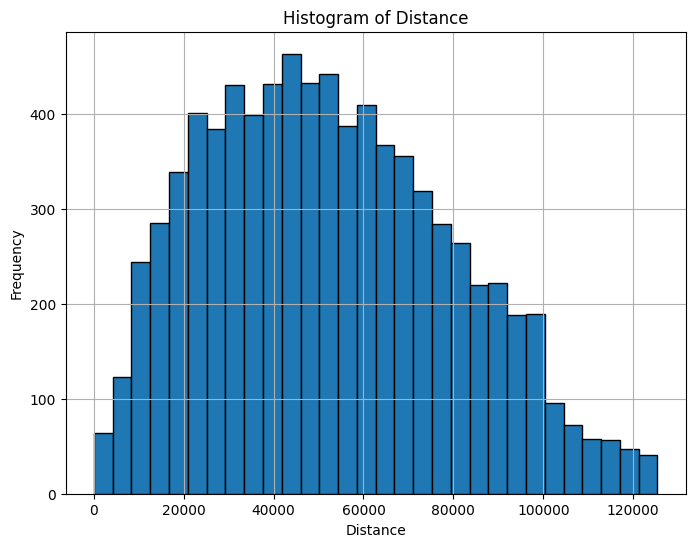

In [141]:
data = df['Distance']

# Create a histogram
plt.figure(figsize=(8, 6))
plt.hist(data, bins=30, edgecolor='black')
plt.title('Histogram of Distance')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Histogram for price

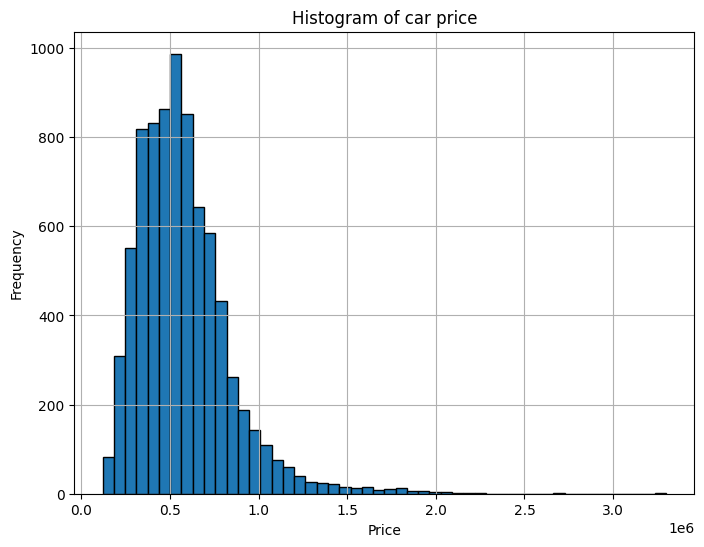

In [146]:
data = df['Price']

# Create a histogram
plt.figure(figsize=(8, 6))
plt.hist(data, bins=50, edgecolor='black')
plt.title('Histogram of car price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Boxplot for price

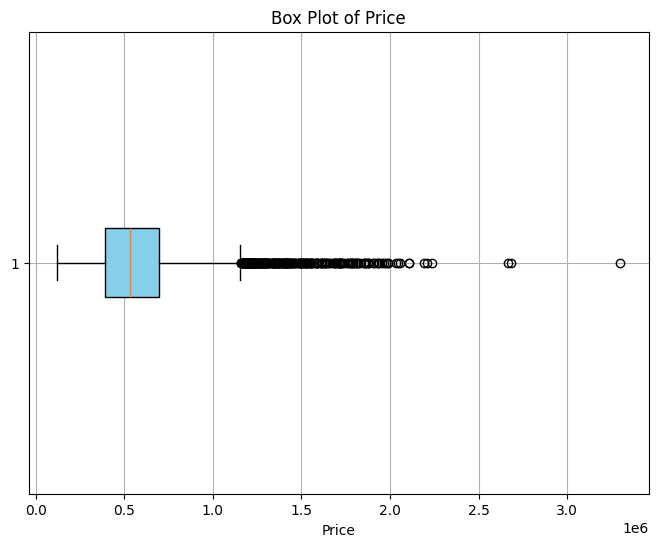

In [147]:
# Sample data
data = df['Price']

# Create a box plot
plt.figure(figsize=(8, 6))
plt.boxplot(data, vert=False, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title('Box Plot of Price')
plt.xlabel('Price')
plt.grid(True)
plt.show()

# 3. Heatmap




A heatmap (or heat map) is a graphical representation of data where values are depicted by color.Heatmaps make it easy to visualize complex data and understand it at a glance 

__Correlation__ - A positive correlation is a relationship between two variables in which both variables move in the same direction. Therefore, when one variable increases as the other variable increases, or one variable decreases while the other decreases.

Correlation can have a value:

- 1 is a perfect positive correlation
- 0 is no correlation (the values don't seem linked at all)
- -1 is a perfect negative correlation



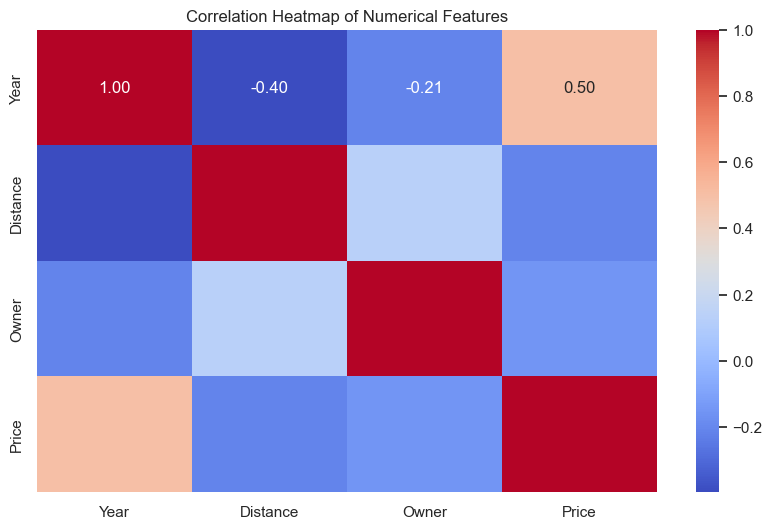

In [155]:

numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
corr = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Heatmap insights: -

As we know, it is recommended to avoid correlated features in your dataset. Indeed, a group of highly correlated features will not bring additional information (or just very few), but will increase the complexity of the algorithm, hence increasing the risk of errors.




### Why Heatmap?

Heatmaps are used to show relationships between two variables, one plotted on each axis. By observing how cell colors change across each axis, you can observe if there are any patterns in value for one or both variables.

# 5. Scatter Plot

Scatter plots are the graphs that present the relationship between two variables in a data-set. It represents data points on a two-dimensional plane or on a Cartesian system. The independent variable or attribute is plotted on the X-axis, while the dependent variable is plotted on the Y-axis. These plots are often called scatter graphs or scatter diagrams.

In [168]:
# Sample data
x = df['Year']
y = df['Price']

# Create a scatter plot with Plotly
fig = px.scatter(df, x='Year', y='Price', opacity=0.5, title='The manufacturing year of the car vs price')

# Show the plot
fig.show()

In [169]:
# Sample data
x = df['Distance']
y = df['Price']

# Create a scatter plot with Plotly
fig = px.scatter(df, x='Distance', y='Price', opacity=0.5, title='Distance driven vs price')

# Show the plot
fig.show()

In [175]:
# Sample data
x = df['Owner']
y = df['Price']

# Create a scatter plot with Plotly
fig = px.scatter(df, x='Owner', y='Price', opacity=0.5, title='The number of previous owners the car has had vs price')
fig.update_xaxes(tickmode='linear', tick0=0, dtick=1)
# Show the plot
fig.show()

In [176]:
# Sample data
x = df['Fuel']
y = df['Price']

# Create a scatter plot with Plotly
fig = px.scatter(df, x='Fuel', y='Price', opacity=0.5, title='Fuel of car vs price')

# Show the plot
fig.show()

In [177]:
# Sample data
x = df['Location']
y = df['Price']

# Create a scatter plot with Plotly
fig = px.scatter(df, x='Location', y='Price', opacity=0.5, title='Location vs price')

# Show the plot
fig.show()

In [178]:
# Sample data
x = df['Car Name']
y = df['Price']

# Create a scatter plot with Plotly
fig = px.scatter(df, x='Car Name', y='Price', opacity=0.5, title='Car Name vs price')

# Show the plot
fig.show()

In [184]:
# Sample data
x = df['Type']
y = df['Price']

# Create a scatter plot with Plotly
fig = px.scatter(df, x='Type', y='Price', opacity=0.5, title='Type vs price')

# Show the plot
fig.show()

### Why use Scatter plot? 

Scatter plots are used in either of the following situations.

- When we have paired numerical data
- When there are multiple values of the dependent variable for a unique value of an independent variable
- In determining the relationship between variables in some scenarios, such as identifying potential root causes of problems, checking whether two products that appear to be related both occur with the exact cause and so on.

### Save preprocess data

In [187]:
df.to_csv("Dataset/preprocessed_data.csv")